In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("../data/raw")

df = pd.read_csv(DATA_DIR / "listings.csv.gz", compression='gzip', low_memory=False)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (96871, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,https://www.airbnb.com/users/show/54730,Alina,2009-11-16,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,within a few hours,100%,96%,t,https://a0.muscache.com/im/users/54730/profile...,https://a0.muscache.com/im/users/54730/profile...,LB of Islington,2.0,5.0,"['email', 'phone']",...,331,2025-09-16,55,10,1,74,8,92,6440.0,2010-08-18,2025-08-21,4.85,4.80,4.80,4.81,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,https://www.airbnb.com/users/show/60302,Philippa,2009-12-05,"Royal Borough of Kensington and Chelsea, Unite...","English, grandmother, I have travelled quite ...",NaN,NaN,50%,f,https://a0.muscache.com/im/users/60302/profile...,https://a0.muscache.com/im/users/60302/profile...,Chelsea,1.0,1.0,"['email', 'phone']",...,199,2025-09-16,97,1,0,0,2,9,1341.0,2009-12-21,2025-04-05,4.80,4.86,4.87,4.88,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,https://www.airbnb.com/users/show/67564,Liz,2010-01-04,"London, United Kingdom",We are Liz and Jack. We manage a number of ho...,within an hour,88%,88%,t,https://a0.muscache.com/im/users/67564/profile...,https://a0.muscache.com/im/users/67564/profile...,Fitzrovia,3.0,16.0,"['email', 'phone', 'work_email']",...,80,2025-09-16,56,0,0,78,1,0,0.0,2011-03-21,2024-02-19,4.77,4.83,4.72,4.72,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32


In [100]:
print(df.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [101]:
# Regarder le type et un exemple de valeur pour chaque colonne
pd.DataFrame({
    'type': df.dtypes,
    'exemple': df.iloc[0]
})

,type,exemple
id,int64,13913
listing_url,object,https://www.airbnb.com/rooms/13913
scrape_id,int64,20250914034649
last_scraped,object,2025-09-16
source,object,city scrape
...,...,...
calculated_host_listings_count,int64,2
calculated_host_listings_count_entire_homes,int64,1
calculated_host_listings_count_private_rooms,int64,1
calculated_host_listings_count_shared_rooms,int64,0


In [ ]:
cols_to_keep = [
    
    # Localisation
    'neighbourhood_cleansed', 'latitude', 'longitude',
    
    # Caractéristiques du logement
    'property_type', 'room_type', 'accommodates',
    'bathrooms_text', 'bedrooms', 'beds', 'amenities',
    
    # Hôte
    'host_is_superhost', 'host_identity_verified',
    
    # Disponibilité
    'minimum_nights', 'availability_365',
    
    # Avis
    'number_of_reviews', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location',
    
    # Cible
    'price'
]

df = df[cols_to_keep].copy()
print(f"Shape après sélection : {df.shape}")
df.head(3)

Shape après sélection : (96871, 20)


,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,amenities,host_is_superhost,host_identity_verified,minimum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,price
0,13913,Islington,51.56861,-0.11270,Private room in rental unit,Private room,1,1 shared bath,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",t,t,1,331,55,4.85,4.80,4.78,$70.00
1,15400,Kensington and Chelsea,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",f,t,4,199,97,4.80,4.87,4.93,$149.00
2,17402,Westminster,51.52195,-0.14094,Entire rental unit,Entire home/apt,6,2 baths,3.0,3.0,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",t,t,3,80,56,4.77,4.72,4.89,$411.00


In [103]:
missing = pd.DataFrame({
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_%', ascending=False)

missing[missing['missing'] > 0]

,missing,missing_%
price,34908,36.0
beds,34920,36.0
review_scores_location,24166,24.9
review_scores_cleanliness,24131,24.9
review_scores_rating,24122,24.9
bedrooms,12775,13.2
host_is_superhost,1766,1.8
bathrooms_text,153,0.2
host_identity_verified,41,0.0


In [104]:
# 1. Supprimer les lignes sans prix ni beds
df = df.dropna(subset=['price', 'beds'])
print(f"Après suppression prix/beds : {df.shape}")

# 2. Imputer les scores par la moyenne
score_cols = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_location']
for col in score_cols:
    moyenne = df[col].mean()
    df[col] = df[col].fillna(moyenne)
    print(f"{col} → imputé avec {moyenne:.2f}")

# 3. Imputer bedrooms par la médiane
mediane_bedrooms = df['bedrooms'].median()
df['bedrooms'] = df['bedrooms'].fillna(mediane_bedrooms)
print(f"bedrooms → imputé avec {mediane_bedrooms}")

# 4. Supprimer les lignes restantes avec NaN
df = df.dropna(subset=['host_is_superhost', 'bathrooms_text', 'host_identity_verified'])
print(f"\nShape final : {df.shape}")

# Vérification — plus aucun NaN ?
print(f"Valeurs manquantes restantes : {df.isnull().sum().sum()}")

Après suppression prix/beds : (61834, 20)
review_scores_rating → imputé avec 4.67
review_scores_cleanliness → imputé avec 4.65
review_scores_location → imputé avec 4.72
bedrooms → imputé avec 1.0

Shape final : (60373, 20)
Valeurs manquantes restantes : 0


In [105]:
# Retirer $ et , puis convertir en float
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].astype(float)

print(df['price'].head(10))
print(f"\nType : {df['price'].dtype}")
print(f"Prix min : {df['price'].min():.0f}£")
print(f"Prix max : {df['price'].max():.0f}£")
print(f"Prix médian : {df['price'].median():.0f}£")

0      70.0
1     149.0
2     411.0
4     210.0
5     280.0
6      90.0
7      61.0
8     340.0
9      49.0
11    213.0
Name: price, dtype: float64

Type : float64
Prix min : 7£
Prix max : 1085147£
Prix médian : 135£


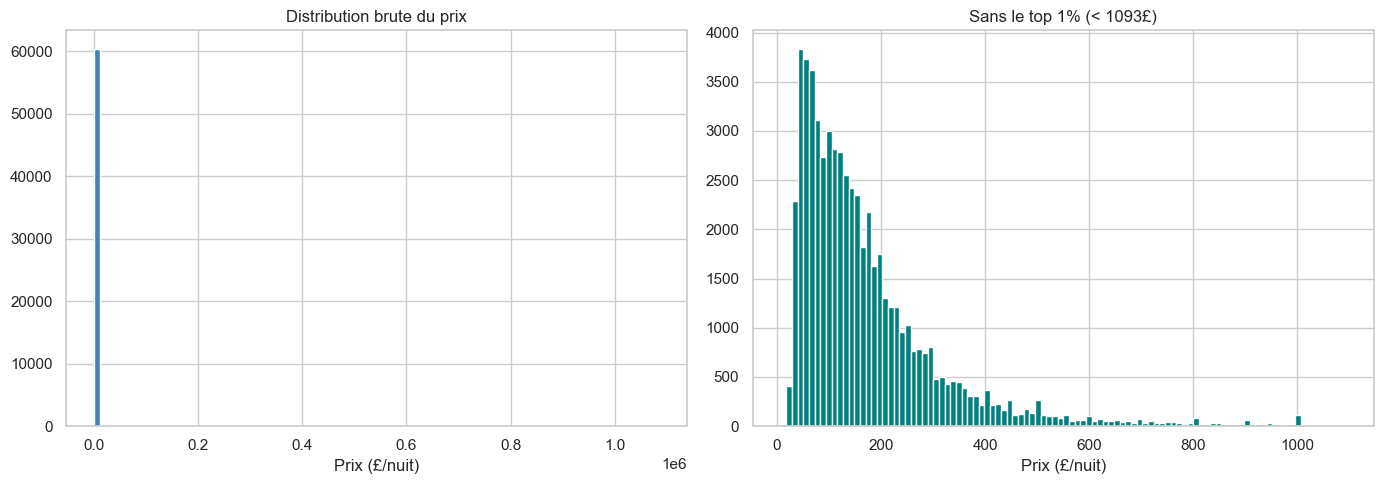

Seuil 99e percentile : 1093£


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution brute du prix')
axes[0].set_xlabel('Prix (£/nuit)')

# Zoom sur les 99% premiers
p99 = df['price'].quantile(0.99)
df_zoom = df[df['price'] <= p99]
axes[1].hist(df_zoom['price'], bins=100, color='teal', edgecolor='white')
axes[1].set_title(f'Sans le top 1% (< {p99:.0f}£)')
axes[1].set_xlabel('Prix (£/nuit)')

plt.tight_layout()
plt.show()

print(f"Seuil 99e percentile : {p99:.0f}£")

In [107]:
percentiles = [0.90, 0.95, 0.99, 0.999]
for p in percentiles:
    print(f"Top {(1-p)*100:.1f}% au-dessus de : {df['price'].quantile(p):.0f}£")

print(f"\nCombien de logements > 500£ : {(df['price'] > 500).sum()}")
print(f"Combien de logements > 1000£ : {(df['price'] > 1000).sum()}")

Top 10.0% au-dessus de : 359£
Top 5.0% au-dessus de : 500£
Top 1.0% au-dessus de : 1093£
Top 0.1% au-dessus de : 9673£

Combien de logements > 500£ : 2956
Combien de logements > 1000£ : 693


In [108]:
# Supprimer le top 1% et les prix trop bas (moins de 10£, probablement des erreurs)
p99 = df['price'].quantile(0.99)
df = df[(df['price'] >= 10) & (df['price'] <= p99)]

print(f"Seuil haut : {p99:.0f}£")
print(f"Shape final : {df.shape}")
print(f"\nPrix min : {df['price'].min():.0f}£")
print(f"Prix max : {df['price'].max():.0f}£")
print(f"Prix médian : {df['price'].median():.0f}£")

Seuil haut : 1093£
Shape final : (59767, 20)

Prix min : 10£
Prix max : 1093£
Prix médian : 134£


In [109]:
df['bathrooms_text'].value_counts().head(10)

bathrooms_text
1 bath              27807
2 baths              8443
1 shared bath        6645
1 private bath       5344
1.5 baths            3334
2.5 baths            1732
1.5 shared baths     1674
3 baths              1216
2 shared baths       1035
3.5 baths             486
Name: count, dtype: int64

In [110]:
# Extraire le nombre de salles de bain
df['bathrooms_count'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)

# Détecter si partagé
df['bathrooms_shared'] = df['bathrooms_text'].str.contains('shared', case=False).astype(int)

# Vérifier
print(df[['bathrooms_text', 'bathrooms_count', 'bathrooms_shared']].head(10))

# Supprimer l'ancienne colonne
df = df.drop(columns=['bathrooms_text'])

    bathrooms_text  bathrooms_count  bathrooms_shared
0    1 shared bath              1.0                 1
1           1 bath              1.0                 0
2          2 baths              2.0                 0
4           1 bath              1.0                 0
5        1.5 baths              1.5                 0
6   0 shared baths              0.0                 1
7   1 private bath              1.0                 0
8          2 baths              2.0                 0
9    1 shared bath              1.0                 1
11          1 bath              1.0                 0


In [111]:
df['amenities'].head(3)

0    ["Self check-in", "Kitchen", "Smoke alarm", "D...
1    ["Kitchen", "Smoke alarm", "Dedicated workspac...
2    ["Kitchen", "Cleaning products", "Smoke alarm"...
Name: amenities, dtype: object

In [112]:
import ast

# Compter le nombre d'équipements uniques
all_amenities = df['amenities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
unique_amenities = set(a for amenities in all_amenities for a in amenities)
print(f"Nombre d'équipements uniques : {len(unique_amenities)}")
print("\nExemples :")
print(list(unique_amenities)[:20])

Nombre d'équipements uniques : 8071

Exemples :
['Faith in natural  body soap', 'Natural mini size shampoo', 'HDTV with Amazon Prime Video, Apple TV, Fire TV, Netflix', '26 inch HDTV with standard cable', 'Hisense stainless steel gas stove', "Tesco's shampoo", 'Kirkland shampoo', 'JBL portable speaker Bluetooth sound system', '65 inch HDTV with Amazon Prime Video, Apple TV, Disney+, Netflix, standard cable', 'No brand conditioner', 'UE Boom Bluetooth sound system', '40 inch HDTV with Amazon Prime Video, Netflix, premium cable, standard cable', 'TV with Roku', '24 inch TV with Fire TV, Netflix, Amazon Prime Video', 'Redken conditioner', "Neal's Yard shampoo", 'Fast wifi – 392 Mbps', 'TV with Fire TV, Netflix', 'Cussons  body soap', 'Shared indoor pool - available all year, open specific hours, heated, olympic-sized']


In [113]:
# Équipements clés à encoder
key_amenities = [
    'Wifi', 'Air conditioning', 'Heating',
    'Kitchen', 'Dishwasher', 'Coffee maker',
    'Smoke alarm', 'Lock on bedroom door',
    'Pool', 'Hot tub', 'Gym', 'Elevator',
    'Washer', 'Dryer', 'Iron', 'Dedicated workspace'
]

# Créer une colonne binaire pour chaque équipement
for amenity in key_amenities:
    col_name = amenity.lower().replace(' ', '_')
    df[col_name] = df['amenities'].str.contains(amenity, case=False, regex=False).astype(int)

# Supprimer la colonne originale
df = df.drop(columns=['amenities'])

# Vérifier
print(f"Shape : {df.shape}")
df[['wifi', 'kitchen', 'pool', 'hot_tub', 'gym']].sum().sort_values(ascending=False)

Shape : (59767, 36)


wifi       58248
kitchen    54304
gym         2272
hot_tub     1312
pool         865
dtype: int64

In [114]:
print(df['room_type'].value_counts())
print(f"\nNombre de catégories : {df['room_type'].nunique()}")

room_type
Entire home/apt    40732
Private room       18801
Shared room          185
Hotel room            49
Name: count, dtype: int64

Nombre de catégories : 4


In [115]:
# Ordinal encoding pour room_type
room_type_order = {
    'Shared room': 0,
    'Private room': 1,
    'Hotel room': 2,
    'Entire home/apt': 3
}

df['room_type'] = df['room_type'].map(room_type_order)
print(df['room_type'].value_counts())

room_type
3    40732
1    18801
0      185
2       49
Name: count, dtype: int64


In [116]:
print(df['property_type'].value_counts())
print(f"\nNombre de catégories : {df['property_type'].nunique()}")

property_type
Entire rental unit             26363
Private room in home            7282
Private room in rental unit     6879
Entire home                     5676
Entire condo                    5534
                               ...  
Shared room                        1
Lighthouse                         1
Religious building                 1
Private room in barn               1
Campsite                           1
Name: count, Length: 78, dtype: int64

Nombre de catégories : 78


In [117]:
df = df.drop(columns=['property_type'])
print(f"Shape : {df.shape}")

Shape : (59767, 35)


In [118]:
print(f"Nombre de quartiers : {df['neighbourhood_cleansed'].nunique()}")
print(df['neighbourhood_cleansed'].value_counts().head(10))

Nombre de quartiers : 33
neighbourhood_cleansed
Westminster               7909
Kensington and Chelsea    4419
Tower Hamlets             4134
Camden                    4103
Southwark                 3119
Hackney                   3102
Wandsworth                2948
Lambeth                   2746
Islington                 2658
Hammersmith and Fulham    2592
Name: count, dtype: int64


In [119]:
# One-hot encoding sur neighbourhood_cleansed
df = pd.get_dummies(df, columns=['neighbourhood_cleansed'], prefix='neighbourhood')

print(f"Shape : {df.shape}")
print(f"Nouvelles colonnes neighbourhood : {[c for c in df.columns if c.startswith('neighbourhood')][:5]}...")

Shape : (59767, 67)
Nouvelles colonnes neighbourhood : ['neighbourhood_Barking and Dagenham', 'neighbourhood_Barnet', 'neighbourhood_Bexley', 'neighbourhood_Brent', 'neighbourhood_Bromley']...


In [120]:
# Convertir t/f en 1/0
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)
df['host_identity_verified'] = (df['host_identity_verified'] == 't').astype(int)

# Convertir les booléens neighbourhood en entiers
neighbourhood_cols = [c for c in df.columns if c.startswith('neighbourhood_')]
df[neighbourhood_cols] = df[neighbourhood_cols].astype(int)

# Vérifier
non_numeric = df.select_dtypes(exclude=['number']).columns.tolist()
print(f"Colonnes non numériques restantes : {non_numeric}")

Colonnes non numériques restantes : []


In [122]:
# Imputer bathrooms_count par la médiane
df['bathrooms_count'] = df['bathrooms_count'].fillna(df['bathrooms_count'].median())

# Vérifier
print(f"NaN restants : {df.isnull().sum().sum()}")

NaN restants : 0


In [123]:
df.to_csv("../data/processed/listings_clean.csv", index=False)
print(f"Dataset sauvegardé : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

Dataset sauvegardé : (59767, 67)
Colonnes : ['id', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'host_is_superhost', 'host_identity_verified', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'price', 'bathrooms_count', 'bathrooms_shared', 'wifi', 'air_conditioning', 'heating', 'kitchen', 'dishwasher', 'coffee_maker', 'smoke_alarm', 'lock_on_bedroom_door', 'pool', 'hot_tub', 'gym', 'elevator', 'washer', 'dryer', 'iron', 'dedicated_workspace', 'neighbourhood_Barking and Dagenham', 'neighbourhood_Barnet', 'neighbourhood_Bexley', 'neighbourhood_Brent', 'neighbourhood_Bromley', 'neighbourhood_Camden', 'neighbourhood_City of London', 'neighbourhood_Croydon', 'neighbourhood_Ealing', 'neighbourhood_Enfield', 'neighbourhood_Greenwich', 'neighbourhood_Hackney', 'neighbourhood_Hammersmith and Fulham', 'neighbourhood_Haringey', 'neighbourhood_Harrow', 'neighbourhood_Havering', 'ne